# RetainIQ — Customer Value Segmentation (RFM-Style K-Means)

A new analytical capability, not a Phase 1 EDA deep-dive: nothing in the repo groups customers by commercial value today. All logic lives in `src/models/segmentation.py` — this notebook only calls into it and renders the results.

**RFM substitution note:** classic RFM (Recency / Frequency / Monetary) assumes repeat-purchase transaction history, which this dataset does not have (one row per customer, no order log). Here, `tenure` stands in for Recency/loyalty, `MonthlyCharges` stands in for Monetary spend, and a derived `ServiceCount` (breadth of subscribed services) stands in for Frequency/engagement depth. See `.claude/specs/04-customer-segmentation.md` for the full methodology decision.

In [1]:
import sys
from pathlib import Path

# Allow `import src...` when the notebook is run from notebooks/
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
from IPython.display import Image, display

from src.data.config import FIGURES_DIR
from src.data.load_data import load_clean_data
from src.models.segmentation import (
    VALUE_SEGMENT_LABELS,
    build_segmentation_features,
    generate_segmentation_figures,
    segment_summary,
    silhouette_diagnostic,
)

pd.set_option("display.max_columns", None)
df = load_clean_data()
df.shape

(7043, 20)

Regenerate the segmentation charts before rendering any of them below, so the images this notebook displays are always current for whatever `df` was just loaded.

In [2]:
paths = generate_segmentation_figures(df)
print(f"Saved {len(paths)} figures to reports/figures/")

Saved 2 figures to reports/figures/


## 1. RFM-style feature construction

Three axes feed the clustering: `tenure` (Recency/loyalty proxy), `MonthlyCharges` (Monetary), and `ServiceCount` (Frequency proxy — count of `"Yes"` across 8 service add-on columns, plus 1 if the customer has any internet plan). `Churn` is never part of this feature set — see `build_segmentation_features`'s leakage guard, directly tested in `tests/test_segmentation.py`.

In [3]:
features = build_segmentation_features(df)
features.describe()

,tenure,MonthlyCharges,ServiceCount
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,4.146244
std,24.559481,30.090047,2.312720
min,0.000000,18.250000,1.000000
25%,9.000000,35.500000,2.000000
50%,29.000000,70.350000,4.000000
75%,55.000000,89.850000,6.000000
max,72.000000,118.750000,9.000000


`ServiceCount`'s observed range is 1–9 (0 is possible but no customer in this dataset has zero services — everyone has at least phone or internet).

## 2. K-Means fit and silhouette diagnostic (disclosure, not a k-selection search)

`k=3` is fixed to match the requested Low/Mid/High business tiers — it is **not** chosen by this diagnostic. The table below is reported for transparency only.

In [4]:
diagnostic = silhouette_diagnostic(df)
display(diagnostic)

,k,silhouette_score
0,2,0.4216
1,3,0.4200
2,4,0.4267
3,5,0.3850
4,6,0.4012


Silhouette scores across `k=2..6` are essentially flat (0.42, 0.42, 0.43, 0.39, 0.40) — no `k` in a plausible range is meaningfully better than `k=3` by this metric. This confirms `k=3` is a deliberate business choice (High/Mid/Low value tiers), not one an elbow/silhouette search would have selected on its own, and that's stated here rather than implied.

## 3. Segment summary

In [5]:
display(segment_summary(df))

,segment,customers,avg_tenure,avg_monthly_charges,avg_service_count,churn_rate
0,Low,2151,27.73,26.21,1.56,14.41
1,Mid,2575,14.22,74.43,4.10,46.33
2,High,2317,56.86,89.81,6.59,15.80


The three segments read as commercially sensible profiles:

- **High** (2,317 customers): tenure 56.86 mo, MonthlyCharges $89.81, ServiceCount 6.59 — long-tenured, heavily-subscribed customers.
- **Low** (2,151 customers): tenure 27.73 mo, MonthlyCharges $26.21, ServiceCount 1.56 — light, low-spend accounts.
- **Mid** (2,575 customers): tenure 14.22 mo, MonthlyCharges $74.43, ServiceCount 4.10 — newly-acquired, higher-bill customers who haven't yet built up tenure or service depth.

## 4. Segment profile chart

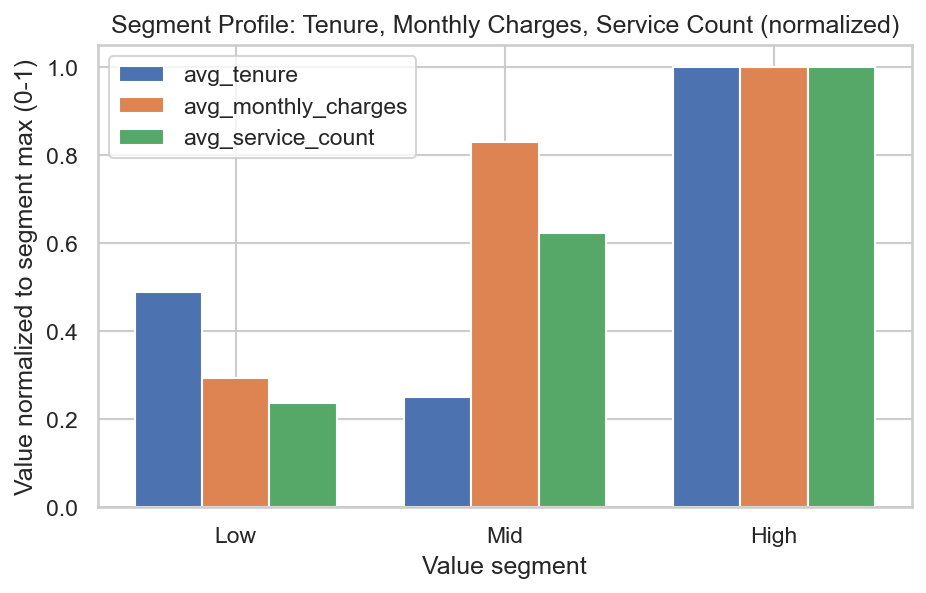

In [6]:
display(Image(str(FIGURES_DIR / "segment_profile.png")))

## 5. Churn rate by value segment

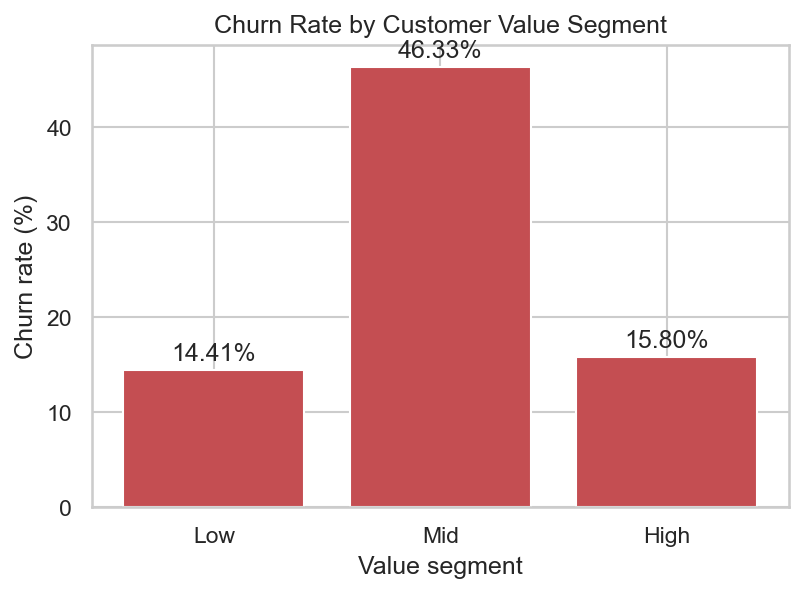

In [7]:
display(Image(str(FIGURES_DIR / "segment_churn_rate.png")))

**The headline finding is counter-intuitive: churn is not monotonic in value.** Low = 14.41%, High = 15.80%, but **Mid = 46.33%** — nearly 3x the other two segments. The segment carrying the most churn risk is not the cheapest one, it's the newly-acquired, higher-paying one that hasn't stuck around long enough to prove out. Mid-segment customers are simultaneously valuable *and* at high risk, unlike Low customers, which sharpens where retention spend should go.

## Key findings

- **Three value segments split roughly evenly and are reproducible**: Low = 2,151 customers, Mid = 2,575, High = 2,317 (sums to 7,043). Refitting the same pipeline twice with `random_state=42` produces bit-identical cluster labels and centers.
- **Segment profiles are commercially sensible**: High reads as long-tenured, heavily-subscribed customers; Low reads as light, low-spend accounts; Mid reads as newly-acquired, higher-bill customers still early in the relationship.
- **Churn is not monotonic in value — the Mid segment is the real risk group**: 46.33% churn vs. 14.41% (Low) and 15.80% (High), nearly 3x the other two segments. This sharpens CLAUDE.md §6's tenure/contract signals into an actionable retention target: newly-acquired, higher-paying customers, not the cheapest ones, deserve the retention focus.
- **`k=3` is a disclosed business choice, not a metric-optimal one**: silhouette scores for `k=2..6` are essentially flat (0.39–0.43), so no `k` is meaningfully better by that metric — `k=3` matches the requested High/Mid/Low tiers, stated here rather than presented as data-driven cluster selection it wasn't.